In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [27]:
df = yf.download("TATASTEEL.NS", start="2020-01-01", end="2024-01-01")
df.columns = df.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed


In [28]:
df

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-01,39.250175,39.984412,39.002631,39.690715,121005300
2020-01-02,40.685081,40.932622,39.606803,39.606803,216749610
2020-01-03,40.588577,40.798359,40.231949,40.529839,129568630
2020-01-06,39.711693,40.278103,39.485128,40.278103,96016080
2020-01-07,39.950840,40.664097,39.736862,39.900491,131957880
...,...,...,...,...,...
2023-12-22,127.929039,129.078529,126.204796,126.827432,37357334
2023-12-26,129.509583,130.371711,128.791149,129.030627,25936447
2023-12-27,131.425415,133.053861,129.796969,130.132244,48101400


In [29]:
df['SMA_10'] = df['Close'].rolling(10).mean()
df['SMA_50'] = df['Close'].rolling(50).mean()
df['Daily_Return'] = df['Close'].pct_change()

In [30]:
df['Future_Price'] = df['Close'].shift(-5)
df['Target'] = np.where(df['Future_Price'] > df['Close'], 1, 0)

In [31]:
df.dropna(inplace=True)

In [32]:
X = df[['SMA_10', 'SMA_50', 'Daily_Return']]
y = df['Target']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

In [34]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [35]:
y_pred = model.predict(X_test)

In [36]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.5585106382978723


In [37]:
df_test = df.iloc[len(X_train):].copy()
df_test['Prediction'] = y_pred

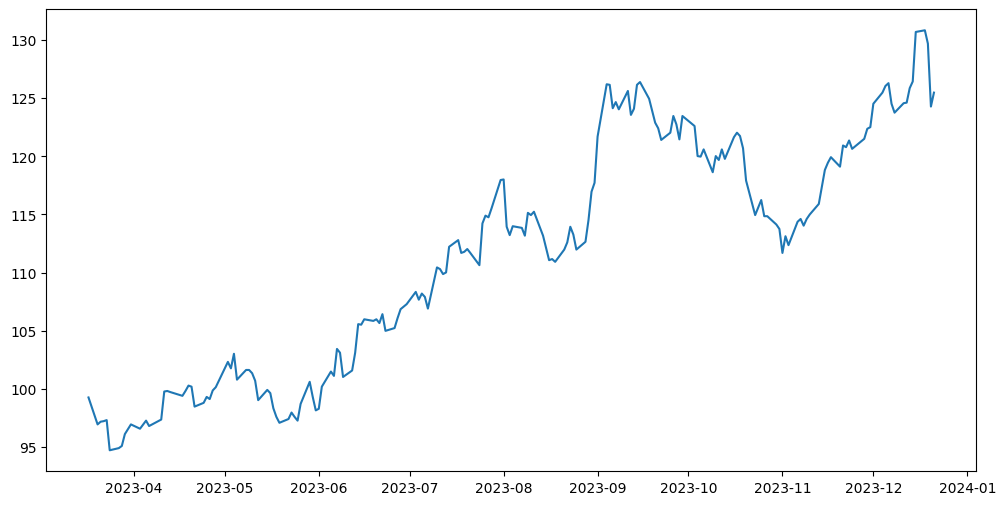

In [38]:
plt.figure(figsize=(12,6))
plt.plot(df_test['Close'], label='Price')
df_test['Signal'] = df_test['Prediction'].map({1: 'BUY', 0: 'SELL'})

In [42]:
print(df_test[['Close', 'Signal']].tail(10))

Price            Close Signal
Date                         
2023-12-08  123.762123    BUY
2023-12-11  124.576347   SELL
2023-12-12  124.624245    BUY
2023-12-13  125.869514   SELL
2023-12-14  126.444267   SELL
2023-12-15  130.706970   SELL
2023-12-18  130.850677   SELL
2023-12-19  129.701157   SELL
2023-12-20  124.288971   SELL
2023-12-21  125.486351   SELL


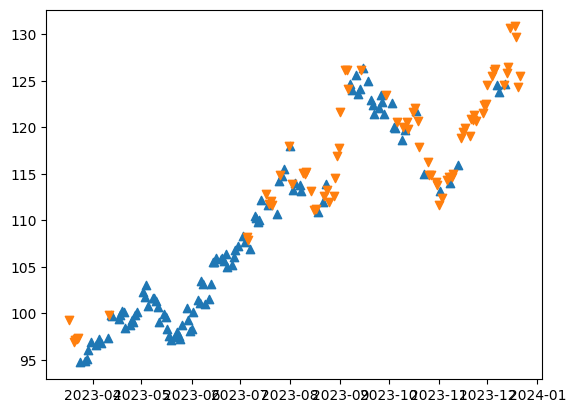

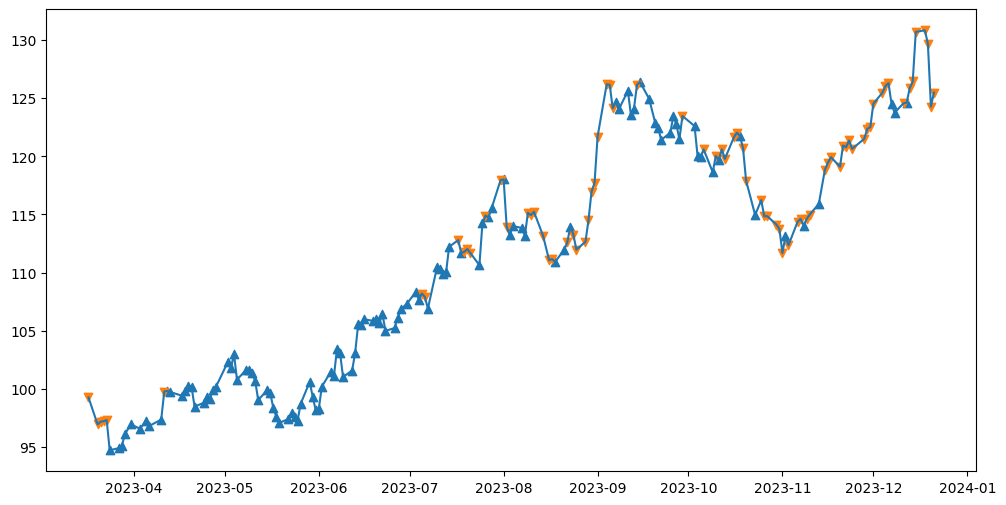

In [44]:
buy = df_test[df_test['Signal'] == 'BUY']
sell = df_test[df_test['Signal'] == 'SELL']

plt.scatter(buy.index, buy['Close'], marker='^', label='BUY')
plt.scatter(sell.index, sell['Close'], marker='v', label='SELL')

plt.figure(figsize=(12,6))

plt.plot(df_test['Close'], label='Stock Price')

buy = df_test[df_test['Signal'] == 'BUY']
sell = df_test[df_test['Signal'] == 'SELL']

plt.scatter(buy.index, buy['Close'], marker='^', label='BUY')
plt.scatter(sell.index, sell['Close'], marker='v', label='SELL')

plt.show()